# Predicting Drug Dissolution with Quantum Machine Learning

**OQI Hackathon 2026** &mdash; classical and quantum ML on the same drug dissolution dataset.

**The task.** 29 crystalline drugs were co-milled with a polymer (PVP K25) to see if that
improves how fast they dissolve. We predict, from the drug's molecular structure alone,
whether co-milling will at least double its dissolution rate ("Responder") or not
("Non-Responder"). We also try to predict the exact improvement ratio as a number.

**What this notebook does.** It walks through the whole project, start to finish: the data,
the features, the classical models, the quantum models, and the bonus experiments. It does
this by calling the real project code in `src/` and `scripts/` &mdash; nothing here is a
simplified re-implementation. Where a step is slow (the full 29-drug quantum evaluation takes
~20&ndash;30 minutes), we run a small live version to prove it works for real, and then load
the full results that were already computed by running `python main.py --stage all`.

**Everything quantum here is real.** Every quantum number in this project, from a kernel value
to a model's prediction, comes from an actual simulated (or real IBM hardware) circuit
execution with measurement shots &mdash; never a shortcut through exact linear algebra.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
from IPython.display import Image, display
from sklearn.preprocessing import MinMaxScaler

from src.config import (
    CLASSIFICATION_TARGET, REGRESSION_TARGET, DESCRIPTORS_CSV, MODELING_TABLE_CSV,
    PLOTS_DIR, RESULTS_DIR, PATZMANN_Q2_BENCHMARK,
)
from src.data_fetching import load_or_fetch_smiles
from src.features import build_descriptor_table, build_modeling_table, get_candidate_matrix, compute_feature_correlations, get_modeling_features
from src.classical_models import run_classical_classification_suite, run_pls_regression_baseline, make_svc
from src.evaluation import summarize_results
from src.quantum_backend import ExecutionConfig, QuantumExecutor
from src.quantum_models import FEATURE_MAPS, compute_quantum_kernel_matrix, run_quantum_classification_suite
from src.evaluation import kernel_target_alignment
from src.bonus_extensions import KTAOptimizedQuantumKernel, execution_degradation_study, fit_deployment_model, BlindPredictor

# Displays one or more already-rendered result images inline.
def show(*filenames):
    for f in filenames:
        display(Image(filename=str(f)))

# Local, free, noiseless simulator. Swap to ExecutionConfig(mode="ibm_runtime")
# (after running scripts/setup_ibm_account.py) to point the exact same code
# at real IBM Quantum hardware -- nothing else in this notebook would change.
EXECUTION_CONFIG = ExecutionConfig(mode="aer_simulator", shots=2048)

## 1. The data

Each drug is represented by a **SMILES** string (a text encoding of its molecular structure).
We already looked these up from PubChem once, so loading is instant here.

The target column, `COMDR_15min`, is the ratio of how much drug dissolved after co-milling vs.
without it. A ratio above 2.0 means co-milling roughly doubled (or more) the dissolution &mdash;
that's a **Responder** (`label_15min = 1`). 13 of the 29 drugs are Responders.

**Important rule:** the raw measurements that `COMDR_15min` is computed from are never allowed
as model features &mdash; that would be leaking the answer into the input. This is enforced in
code (`src/config.py`, `src/features.py`), not just by convention.

In [2]:
smiles_df = load_or_fetch_smiles()
descriptors = pd.read_csv(DESCRIPTORS_CSV) if DESCRIPTORS_CSV.exists() else build_descriptor_table(smiles_df)
data = build_modeling_table(descriptors)
print(f"{len(data)} drugs, {data[CLASSIFICATION_TARGET].sum()} Responders")
data[["drug", "COMDR_15min", "label_15min"]].head()

29 drugs, 13 Responders


,drug,COMDR_15min,label_15min
0,Albendazole,1.802,0
1,Apixaban,8.032,1
2,Apremilast,1.603,0
3,Aripiprazole,6.968,1
4,Candesartan Cilexetil,4.547,1


## 2. Looking at the features before modeling

Every drug gets 14 structural descriptors from RDKit (size, polarity, flexibility, etc.), plus
two experimental measurements: particle size (`D50`) and apparent solubility. That's 16
candidate features in total.

Before picking which ones to model with, we check two things:
- **Correlation with the target** &mdash; which features actually relate to dissolution?
- **Redundancy (PCA)** &mdash; several descriptors measure roughly the same thing (molecule
  size), so using all of them would be wasteful and would give some information more "votes"
  than it deserves.

In [3]:
corr = compute_feature_correlations(data)
print("Top 5 features by correlation with COMDR_15min:")
corr.head()

Top 5 features by correlation with COMDR_15min:


D50                    0.811339
Kappa3                 0.310955
Kappa1                 0.291228
apparent_solubility   -0.275527
Kappa2                 0.236271
dtype: float64

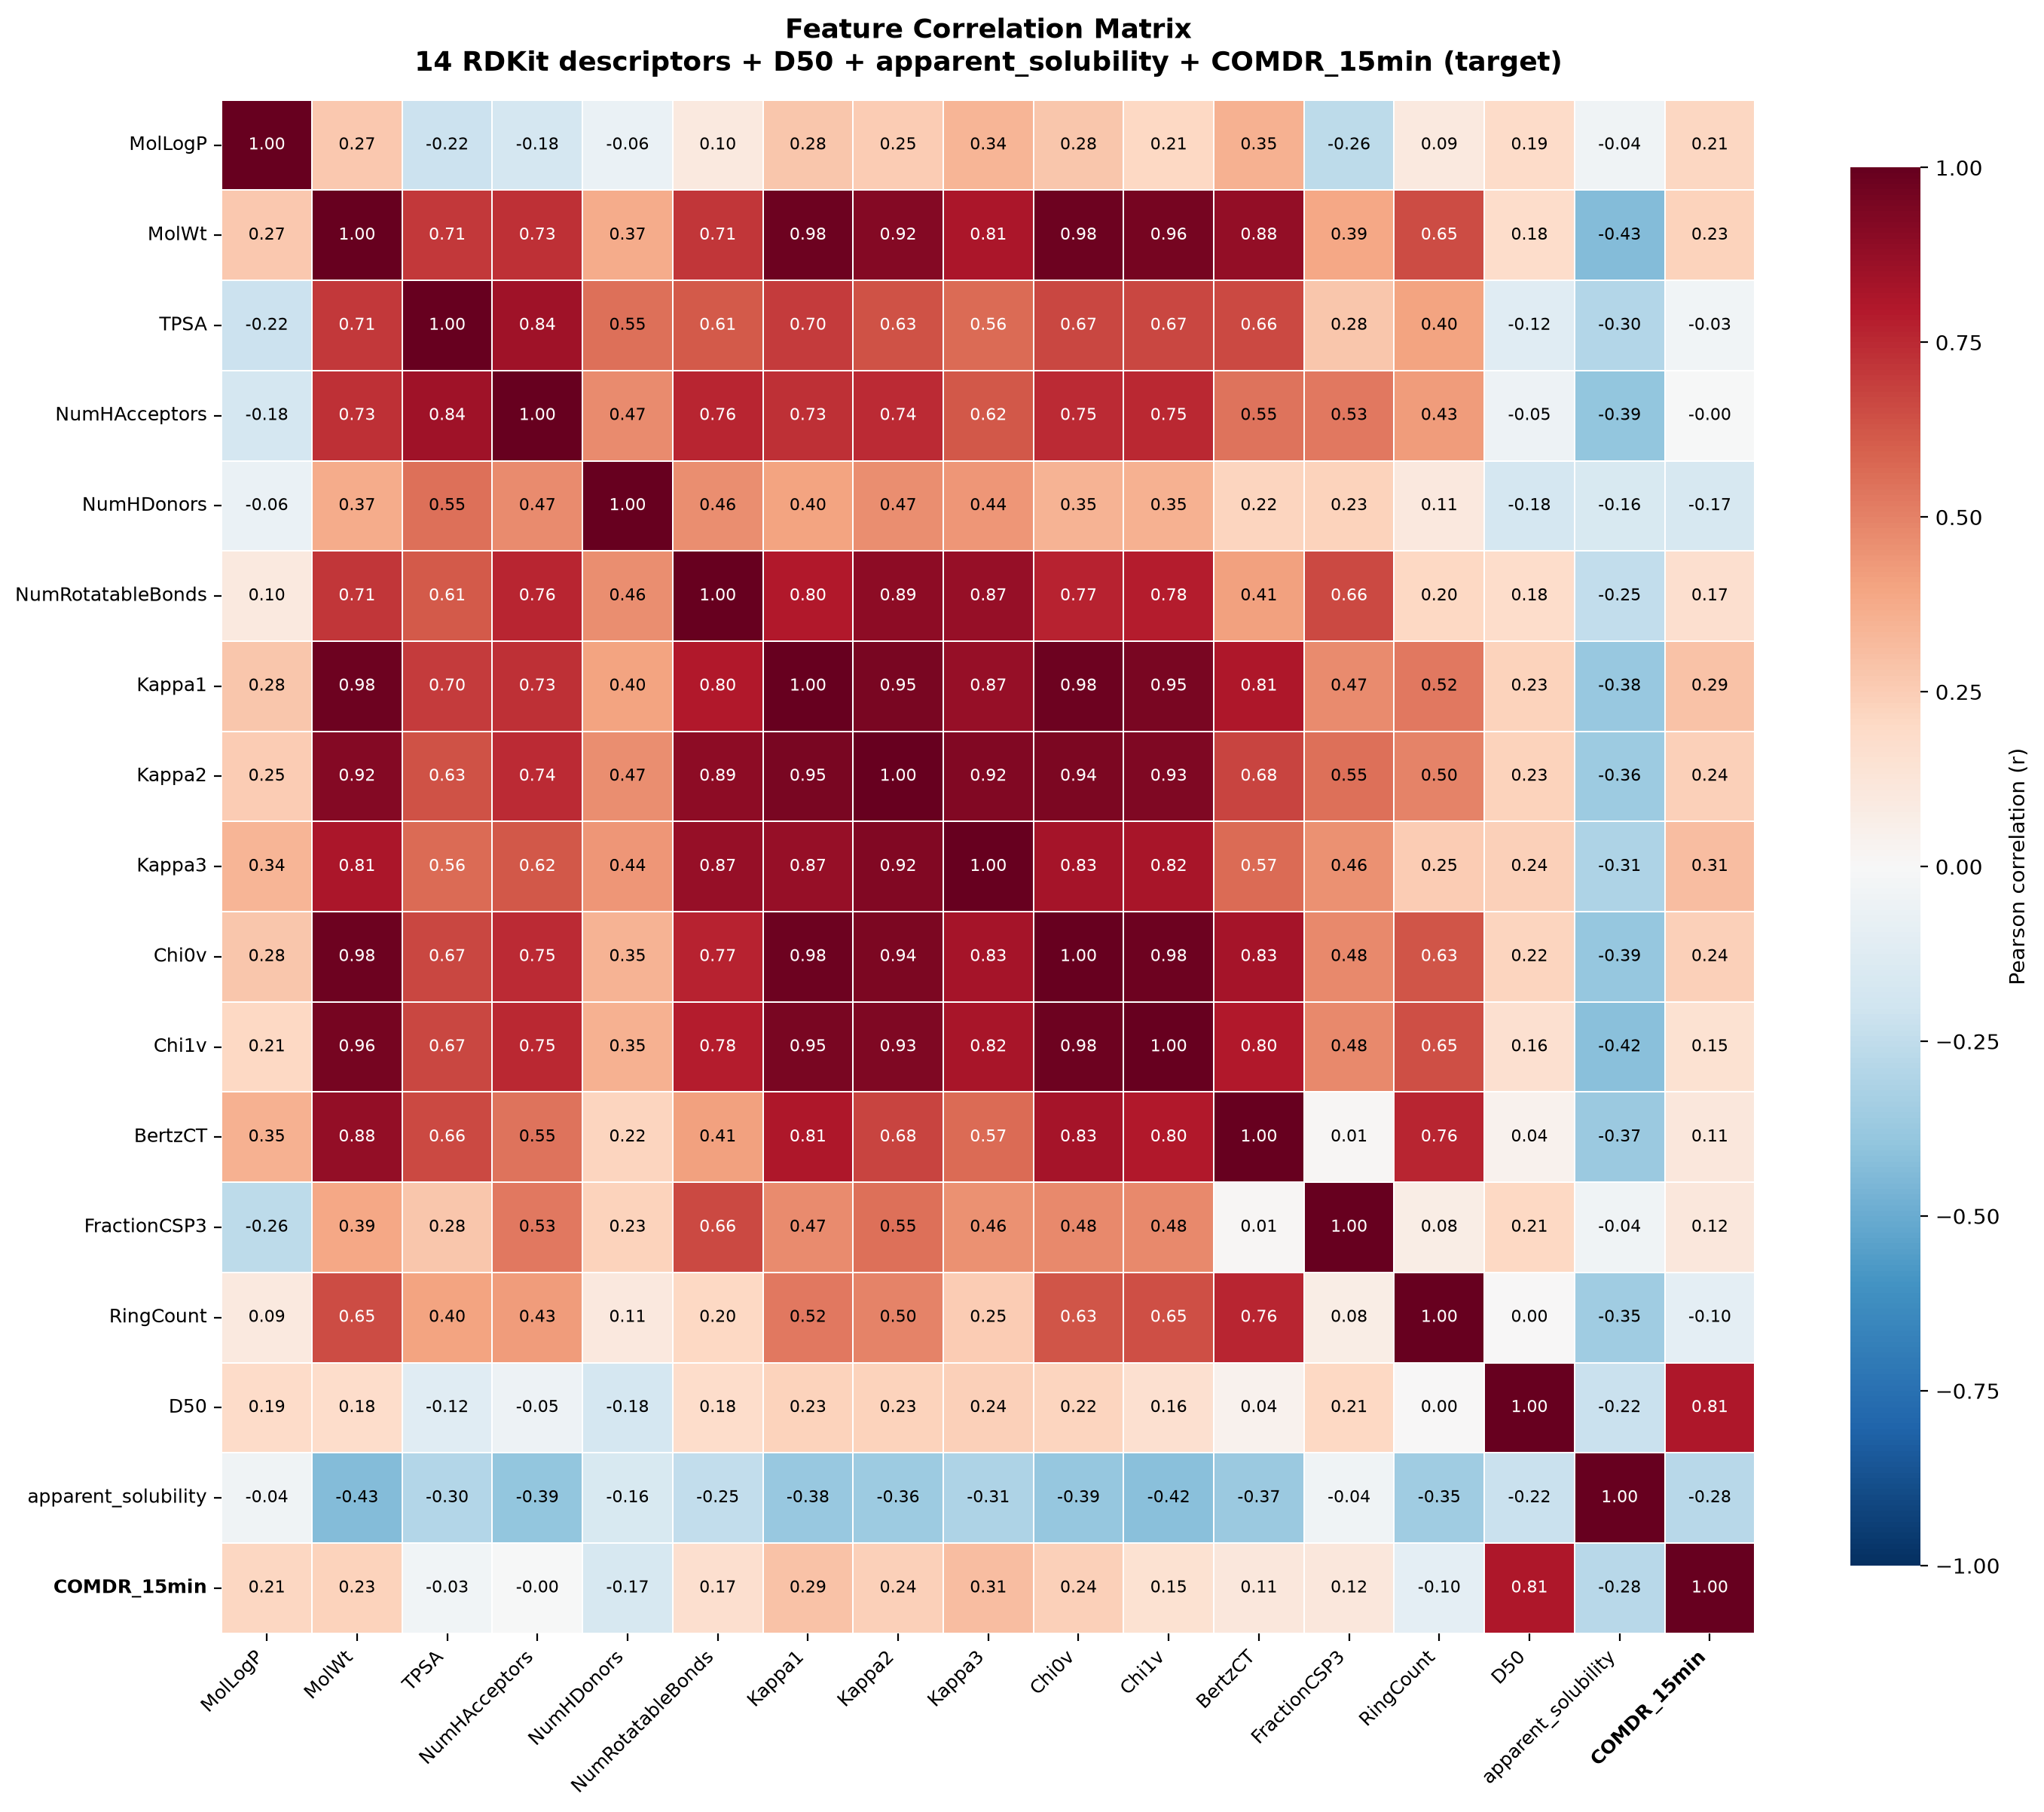

In [4]:
# Full correlation heatmap (all candidate features + target), already rendered by the pipeline.
show(PLOTS_DIR / "feature_correlation_heatmap.png")

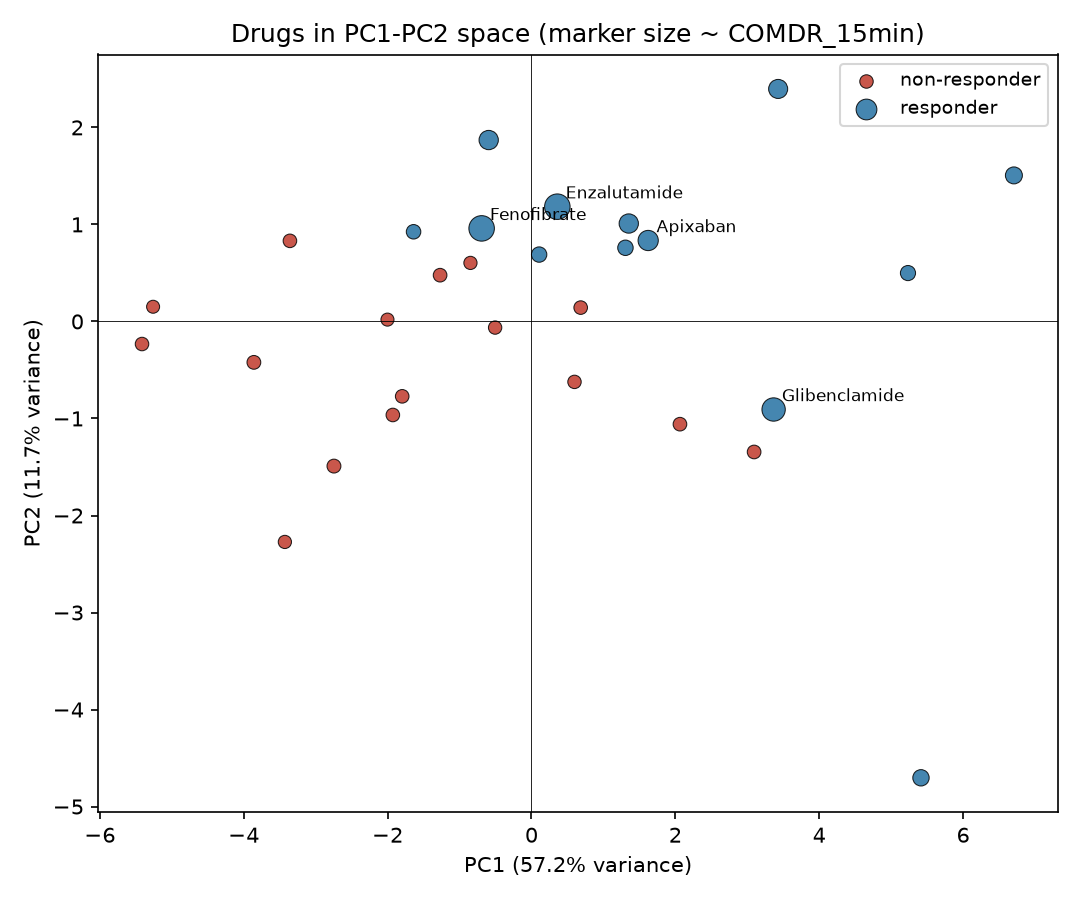

In [5]:
# PC1 vs PC2: each drug in feature space, colored by Responder/Non-Responder.
# Drugs that separate cleanly here are a good sign the features carry real signal.
show(PLOTS_DIR / "pca" / "pca_scatter.png")

## 3. Picking the final feature set

Feature selection is done **inside** a leave-one-out loop, refit on every training fold, so
the held-out drug never influences which features get chosen. This is what keeps every result
later in this notebook honest.

In [6]:
X_full = get_candidate_matrix(data)
y = data[CLASSIFICATION_TARGET]

selection = get_modeling_features(X_full, y)
print("Selected features:", selection["selected_features"])
print("6-feature subset for the fixed 6-qubit QCNN:", selection["features_by_k"][6])

X = X_full[selection["selected_features"]]

Selected features: ['Kappa3', 'D50', 'MolLogP', 'apparent_solubility']
6-feature subset for the fixed 6-qubit QCNN: ['Kappa3', 'D50', 'MolLogP', 'apparent_solubility', 'FractionCSP3', 'BertzCT']


## 4. Classical baselines

Three standard classifiers (SVC, Random Forest, Gradient Boosting) and a PLS regression
baseline, all evaluated the same way as the quantum models: **29-fold leave-one-out cross
validation** (LOOCV) &mdash; train on 28 drugs, test on the 1 left out, repeat for every drug.
With only 29 samples, this uses the data as fairly as possible.

In [7]:
clf_results = run_classical_classification_suite(X, y)
summarize_results(clf_results, kind="classification")

,model,accuracy,f1,recall_class0,recall_class1,n_folds,elapsed_s
0,GradientBoosting,0.931034,0.923077,0.9375,0.923077,29,2.189012
1,RandomForest,0.896552,0.880000,0.9375,0.846154,29,10.522368
2,SVC_rbf,0.862069,0.833333,0.9375,0.769231,29,0.672800


In [8]:
y_reg = data[REGRESSION_TARGET]
pls_result = run_pls_regression_baseline(X, y_reg)
print(f"PLS regression -- Q2 (LOOCV): {pls_result['metrics']['q2_loocv']:.3f}  "
      f"(Patzmann et al. benchmark: {PATZMANN_Q2_BENCHMARK})")

PLS regression -- Q2 (LOOCV): 0.756  (Patzmann et al. benchmark: 0.77)


## 5. Encoding molecules as quantum states

To use a quantum computer, each drug's feature values first need to become a quantum circuit.
We do this with a **feature map**: a circuit where the RDKit/experimental values are used
directly as rotation angles. Below is the simplest one ("angle encoding") for our actual
4-feature set &mdash; this is a real circuit, not a diagram.

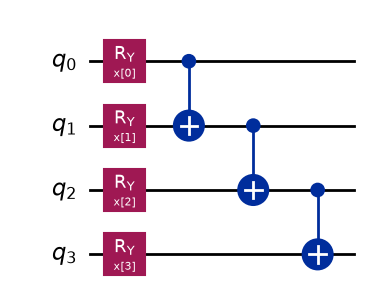

In [9]:
angle_circuit, _ = FEATURE_MAPS["angle"](X.shape[1])
angle_circuit.draw("mpl", fold=-1)

## 6. Quantum kernels and Kernel Target Alignment (KTA)

A **quantum kernel** measures how "similar" two drugs look once encoded into quantum states
(their fidelity). Feeding this similarity matrix into a standard SVM gives a **quantum kernel
SVM**.

**KTA** scores how well that similarity matches the true Responder/Non-Responder labels, from
-1 (backwards) to 1 (perfect). It's a quick diagnostic for whether an encoding is any good
*before* training a full model on it.

In [10]:
kernel_executor = QuantumExecutor(EXECUTION_CONFIG)
X_scaled = MinMaxScaler(feature_range=(0, np.pi)).fit_transform(X.values)
K = compute_quantum_kernel_matrix(X_scaled, kernel_executor, feature_map_name="angle")
print(f"KTA (angle feature map, all 29 drugs): {kernel_target_alignment(K, y.values):.4f}")

KTA (angle feature map, all 29 drugs): 0.2584


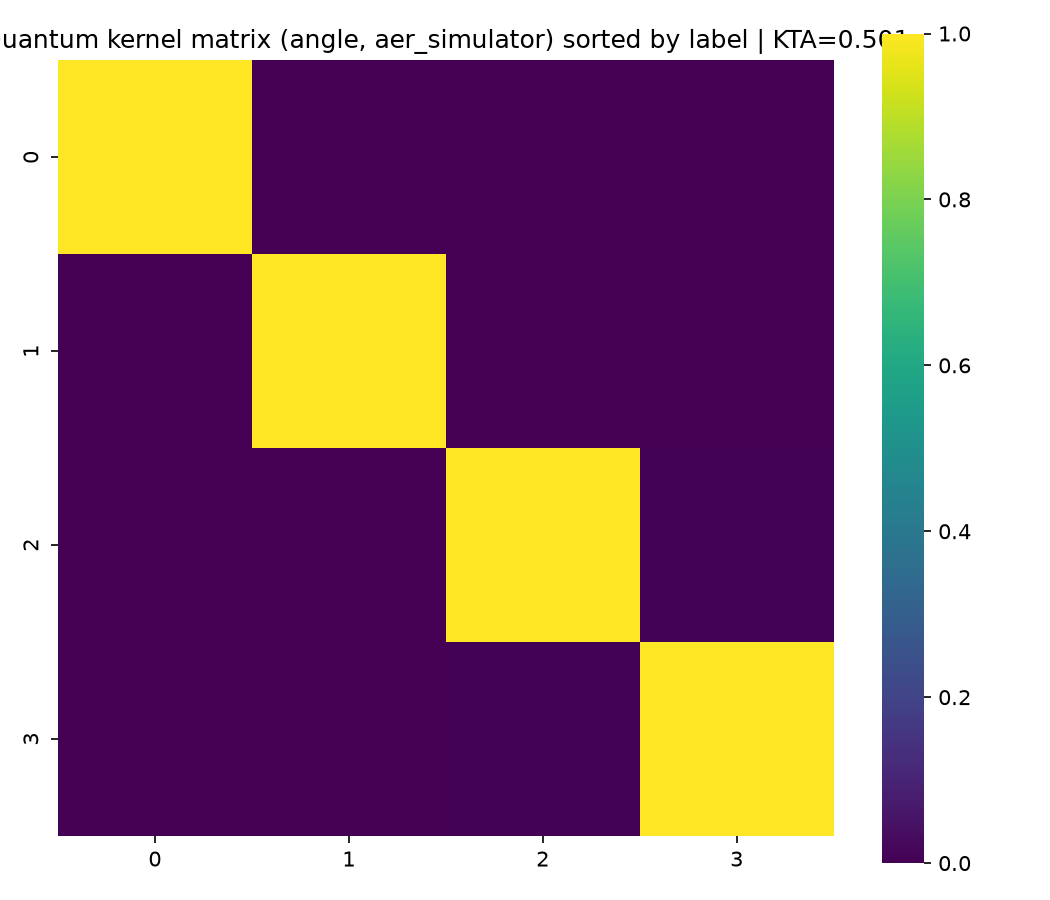

In [11]:
# The full 29x29 kernel, drugs sorted by label -- a block-diagonal pattern would mean
# Responders and Non-Responders already look different to the quantum computer.
show(PLOTS_DIR / "kernels" / "kernel_heatmap_angle.png")

## 7. The quantum models

| Model | Idea |
|---|---|
| **QK-SVM** | Quantum kernel SVM with a fixed feature map |
| **QK-SVM (trained)** | Same, but the feature map has its own trainable weights, optimized to maximize KTA on each training fold |
| **VQC** | A trainable circuit (angles + entangling gates) trained directly on the labels, no kernel |
| **QCNN** | A quantum convolutional network: alternating "conv" and "pool" layers shrink 6 qubits down to 1 |
| **QK-KRR** | Quantum kernel + kernel ridge regression, predicts the ratio directly |
| **VQR / QCNN-R** | Regression versions of VQC / QCNN, reading multiple qubits instead of thresholding one |

Every one of these runs through the same real `SamplerV2` execution path &mdash; only the
circuit shape changes.

In [12]:
# A quick, real demo on 8 drugs (not the full 29) so it finishes in seconds: proof the
# quantum classifier pipeline genuinely executes circuits and produces a result, live.
demo_results = run_quantum_classification_suite(
    X.values[:8], y.values[:8], execution_config=EXECUTION_CONFIG, model_names=["QK-SVM_angle"],
)
summarize_results(demo_results, kind="classification")

,model,accuracy,f1,recall_class0,recall_class1,n_folds,elapsed_s
0,QK-SVM_angle,1.0,1.0,1.0,1.0,8,7.191411


## 8. Full results: classical vs. quantum (all 29 drugs)

The demo above used 8 drugs for speed. The real comparison needs the full 29-drug LOOCV for
every model, which takes ~20&ndash;30 minutes to run (`python main.py --stage all`). That run
has already been done, and its results are loaded here, exactly as they came out &mdash;
nothing below is hand-picked or re-run for this notebook.

In [13]:
unified = pd.read_csv(RESULTS_DIR / "unified_comparison_table.csv")
unified[unified["task"] == "classification"].sort_values("f1", ascending=False)

,task,model,paradigm,accuracy,f1,recall_0,recall_1,q2,r2,mae,rmse,elapsed_s
1,classification,QK-SVM_trained,quantum,0.9655,0.9600,1.0000,0.9231,NaN,NaN,NaN,NaN,1237.7
6,classification,GradientBoosting,classical,0.9310,0.9231,0.9375,0.9231,NaN,NaN,NaN,NaN,0.4
0,classification,QK-SVM_angle,quantum,0.9310,0.9167,1.0000,0.8462,NaN,NaN,NaN,NaN,36.9
5,classification,RandomForest,classical,0.8966,0.8800,0.9375,0.8462,NaN,NaN,NaN,NaN,2.3
2,classification,VQC,quantum,0.8621,0.8333,0.9375,0.7692,NaN,NaN,NaN,NaN,133.5
4,classification,SVC_rbf,classical,0.8621,0.8333,0.9375,0.7692,NaN,NaN,NaN,NaN,0.1
3,classification,QCNN,quantum,0.8621,0.8182,1.0000,0.6923,NaN,NaN,NaN,NaN,219.6


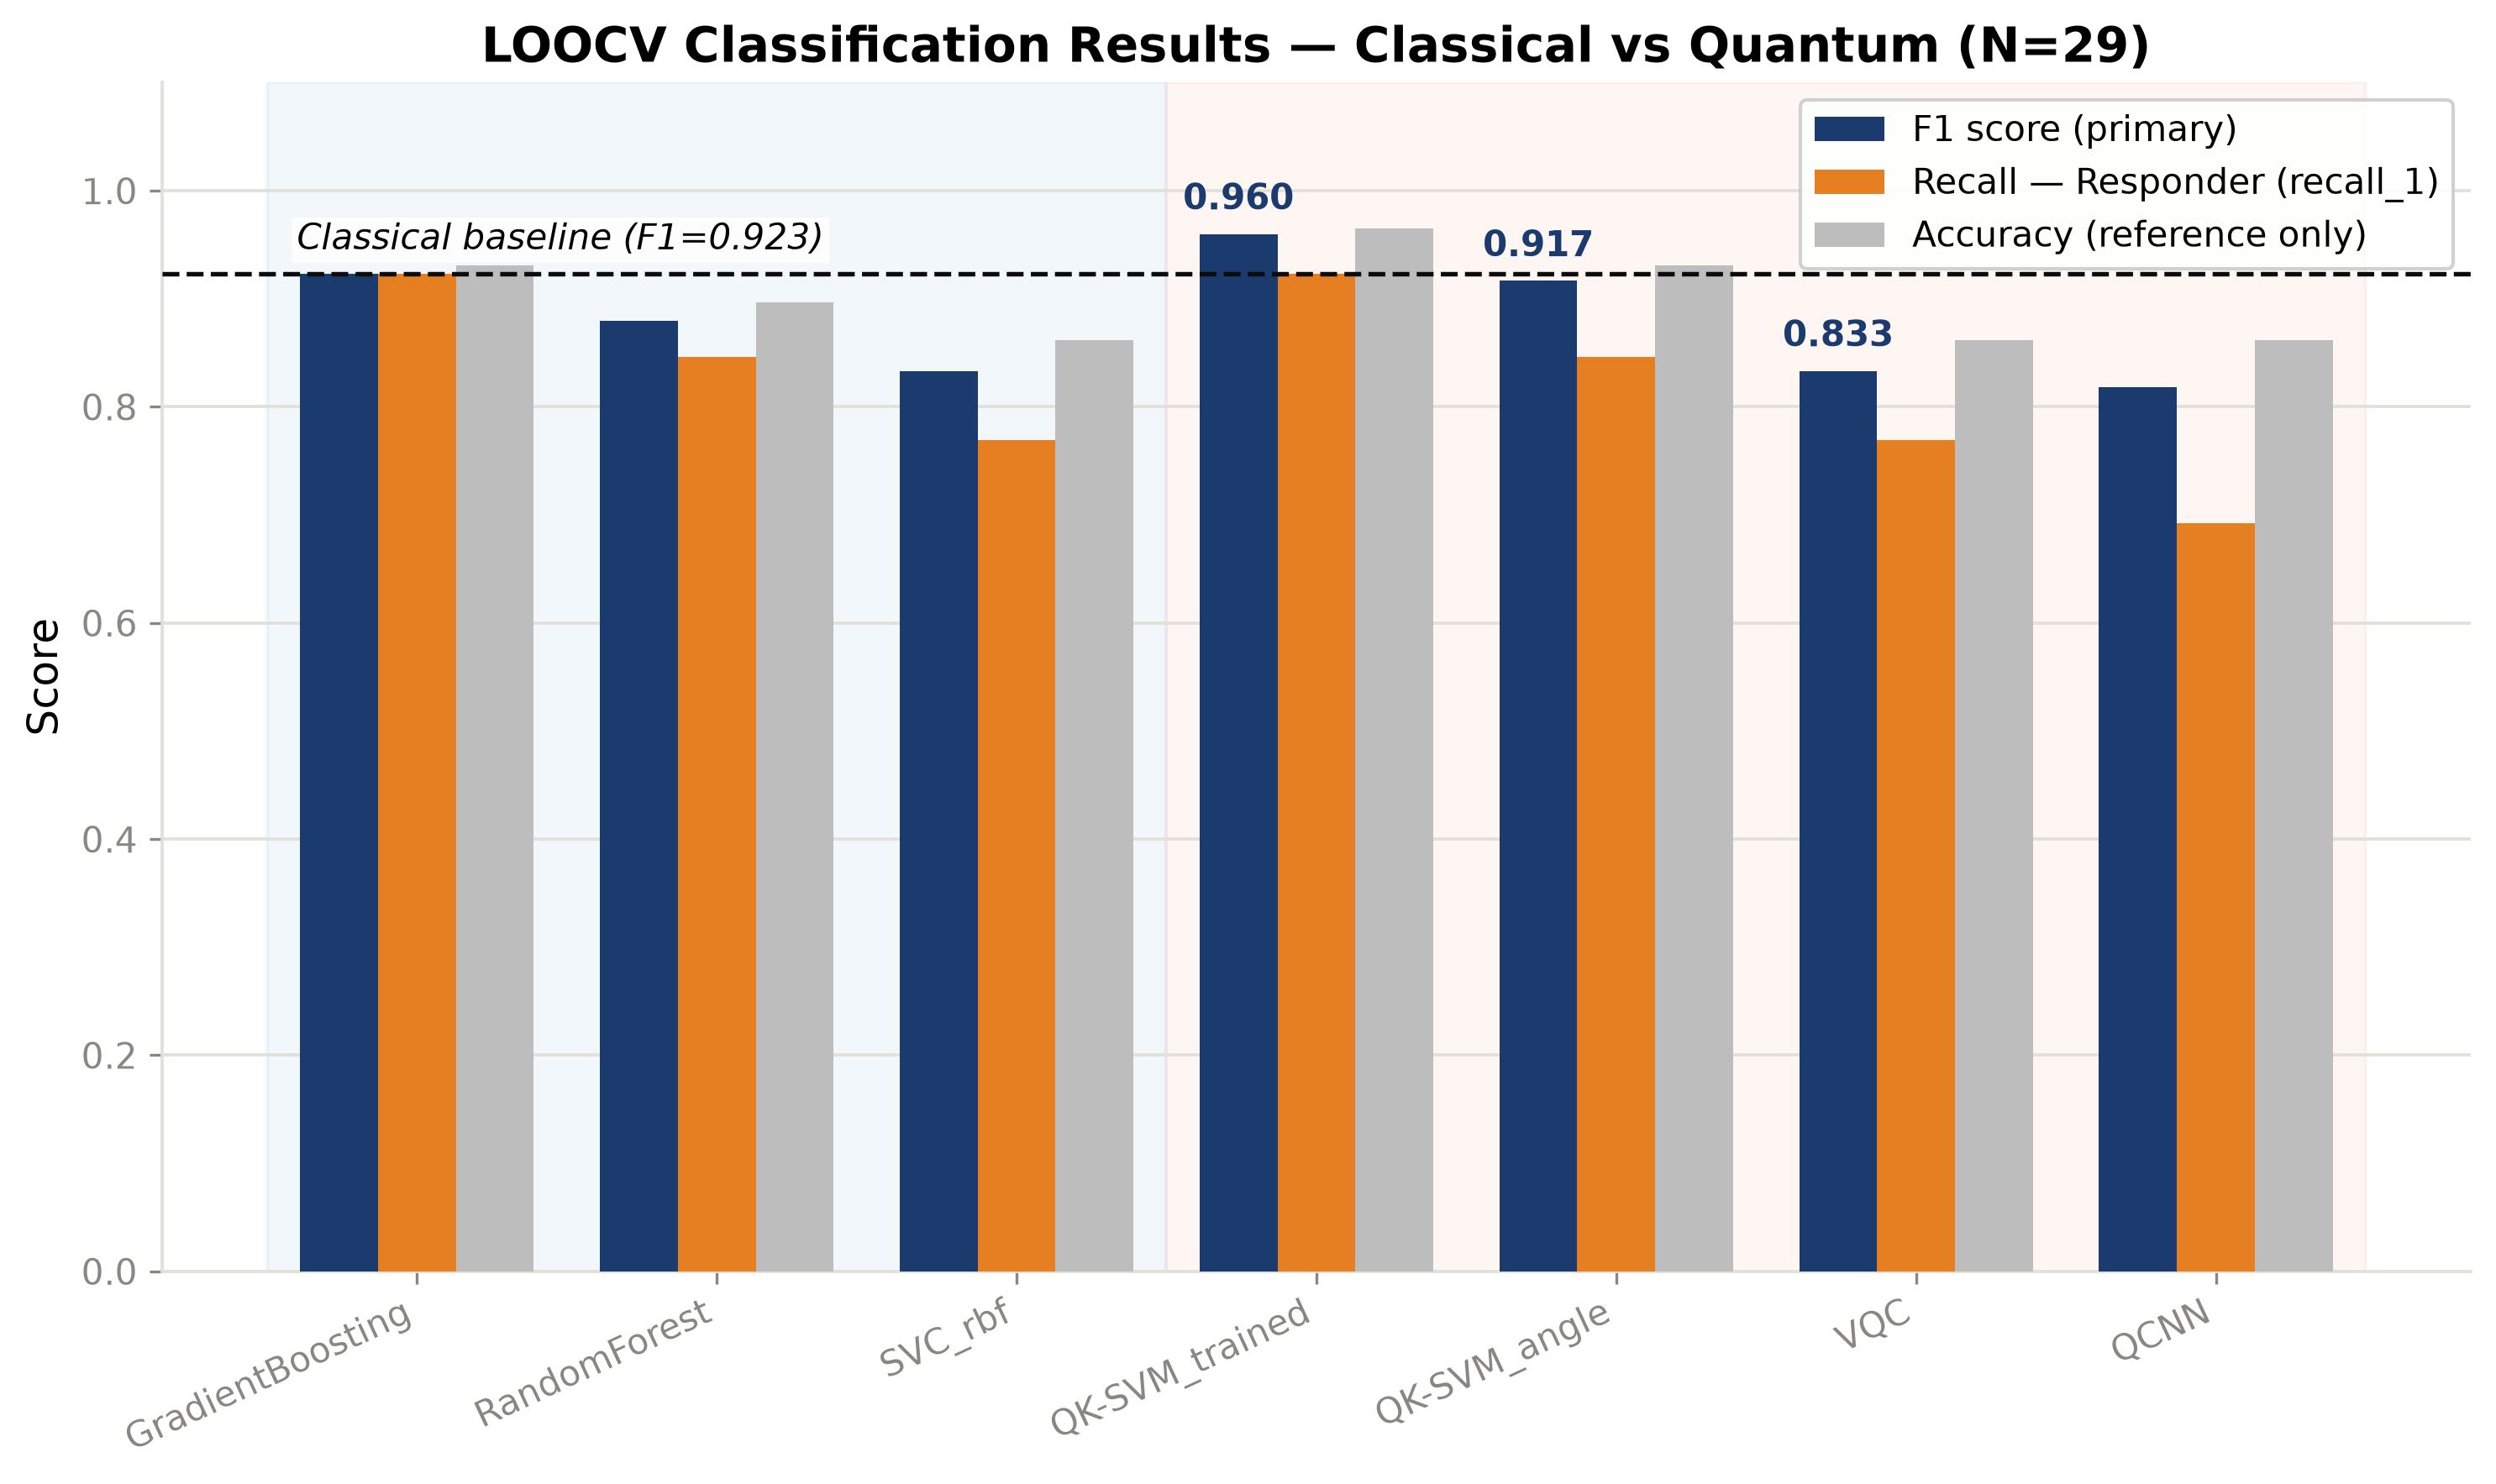

In [14]:
# F1 / recall / accuracy per model, classical vs quantum.
show(PLOTS_DIR / "comparison" / "classification_comparison.png")

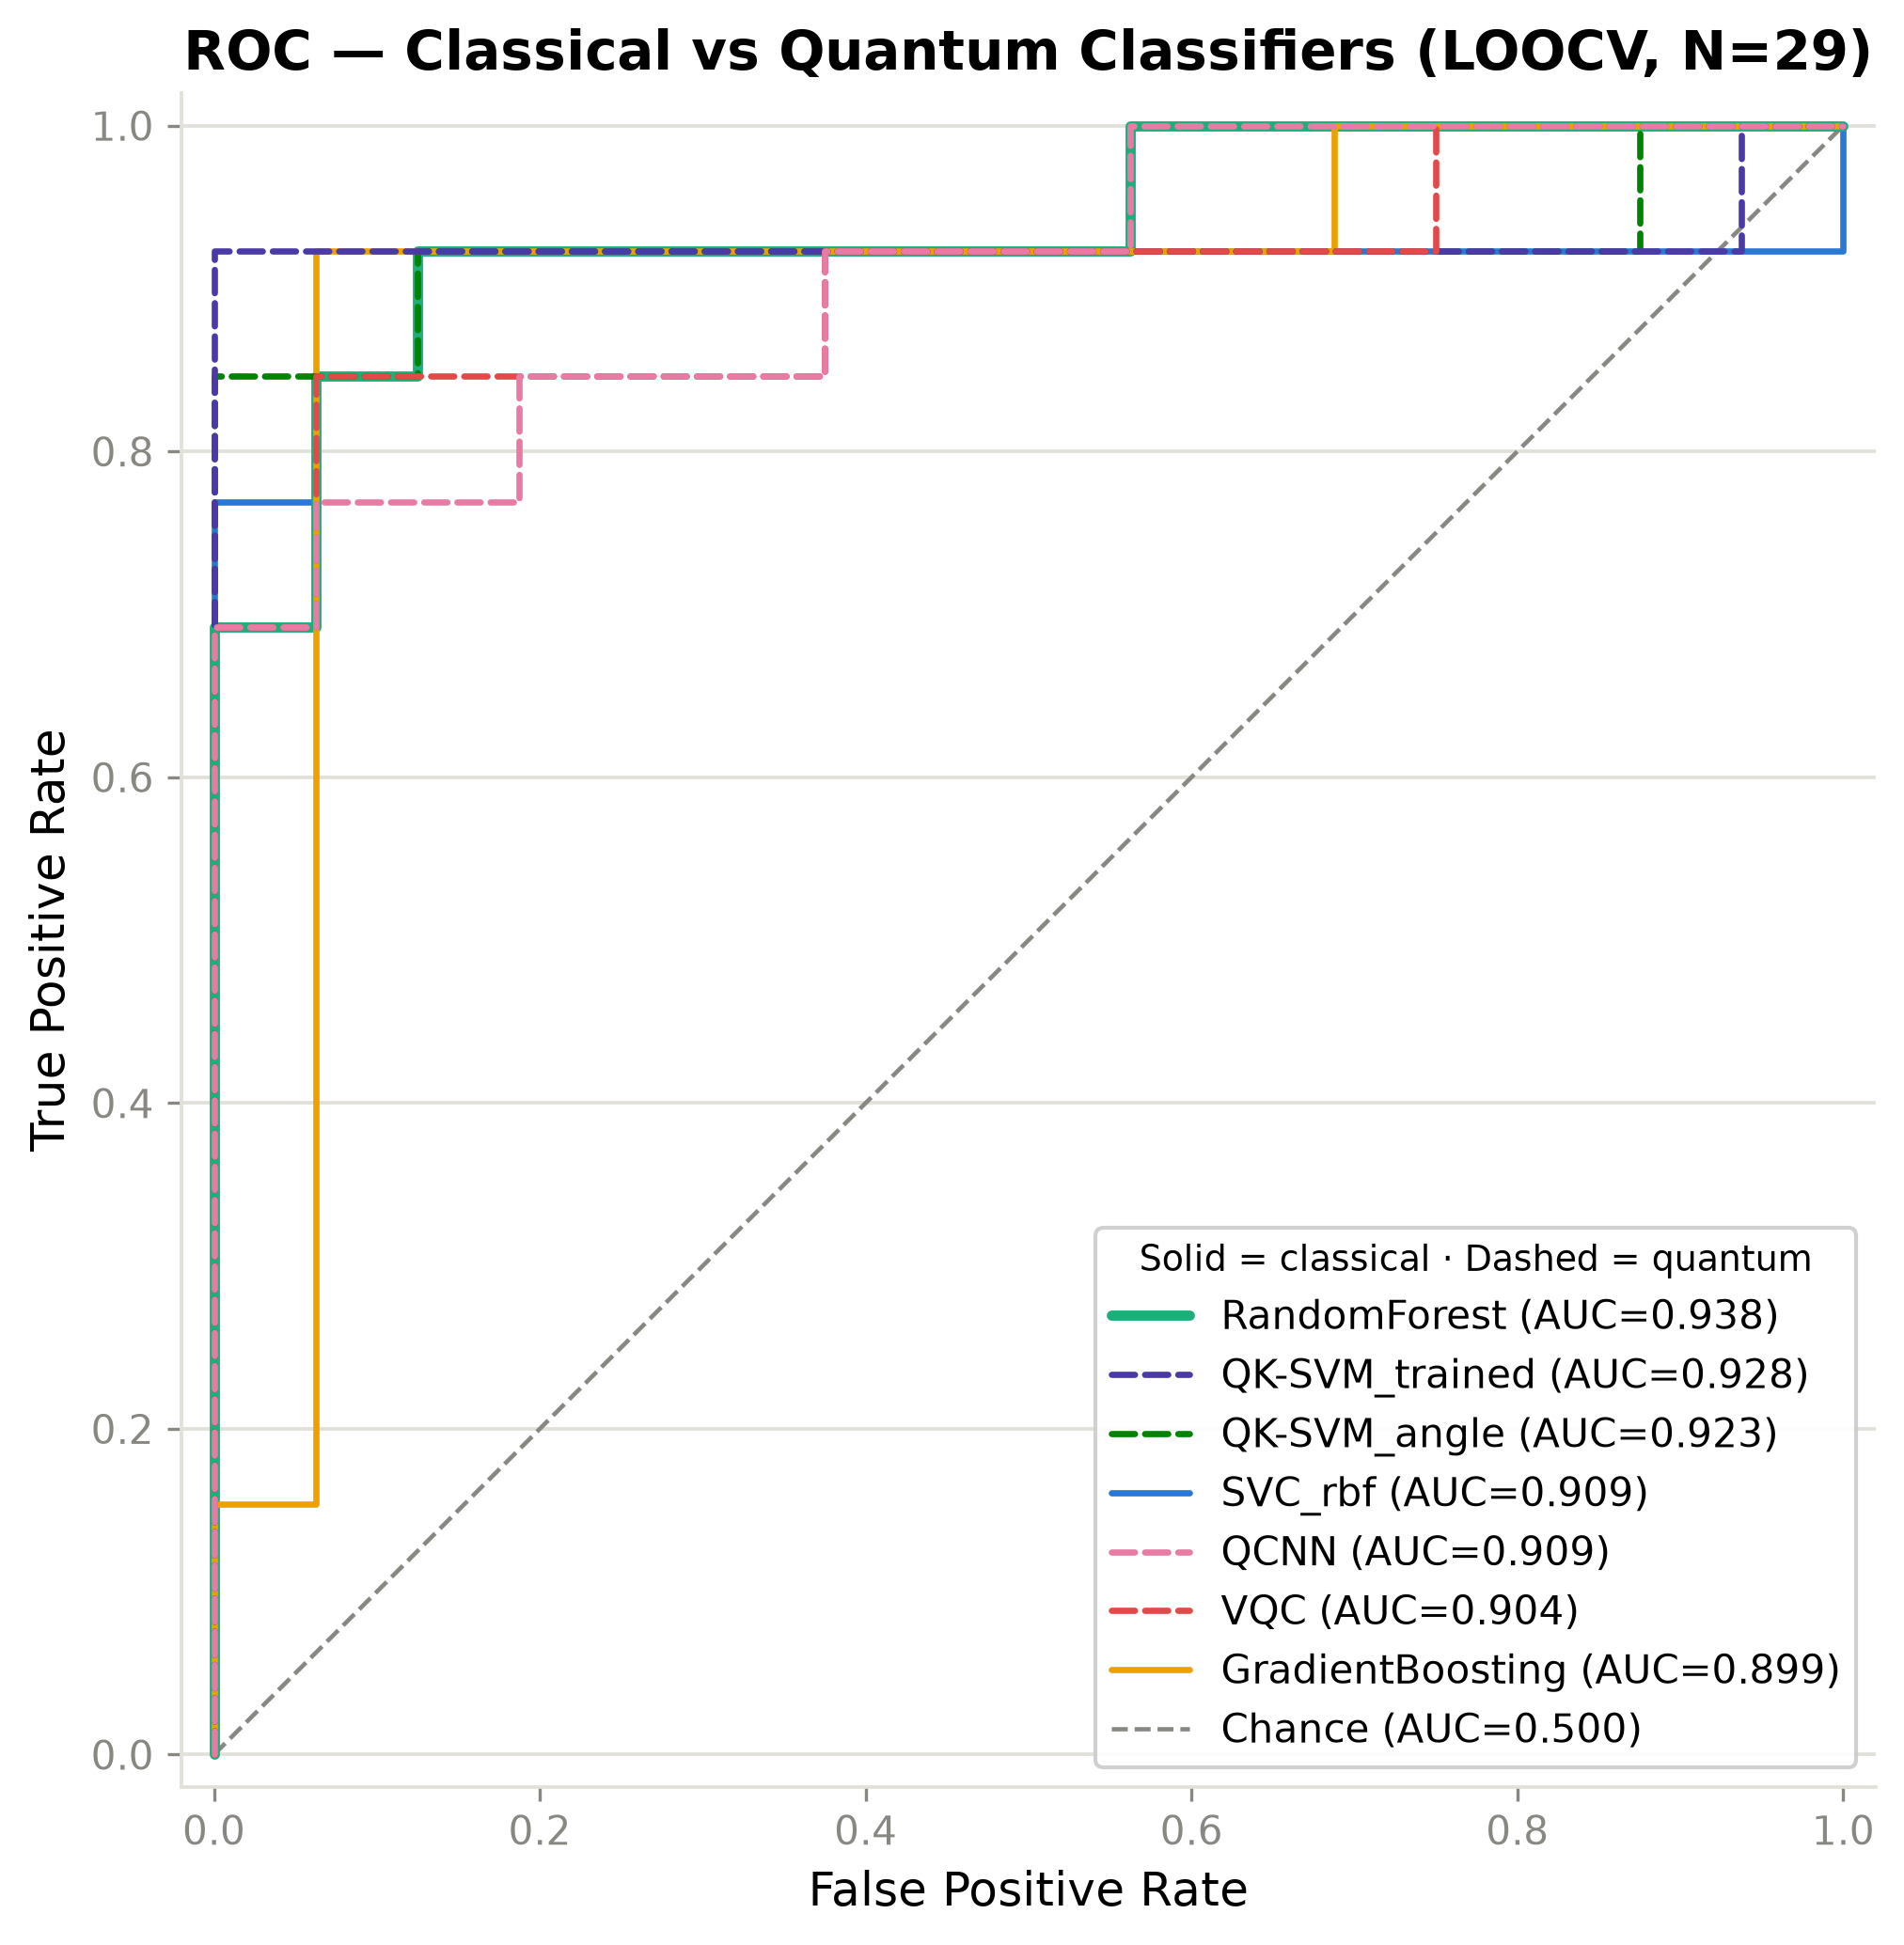

In [15]:
# ROC curves: the clearest single view of whether quantum actually wins, since it compares
# every model across *all* decision thresholds at once, not just the default 0.5 cutoff.
show(PLOTS_DIR / "comparison" / "roc_comparison.png")

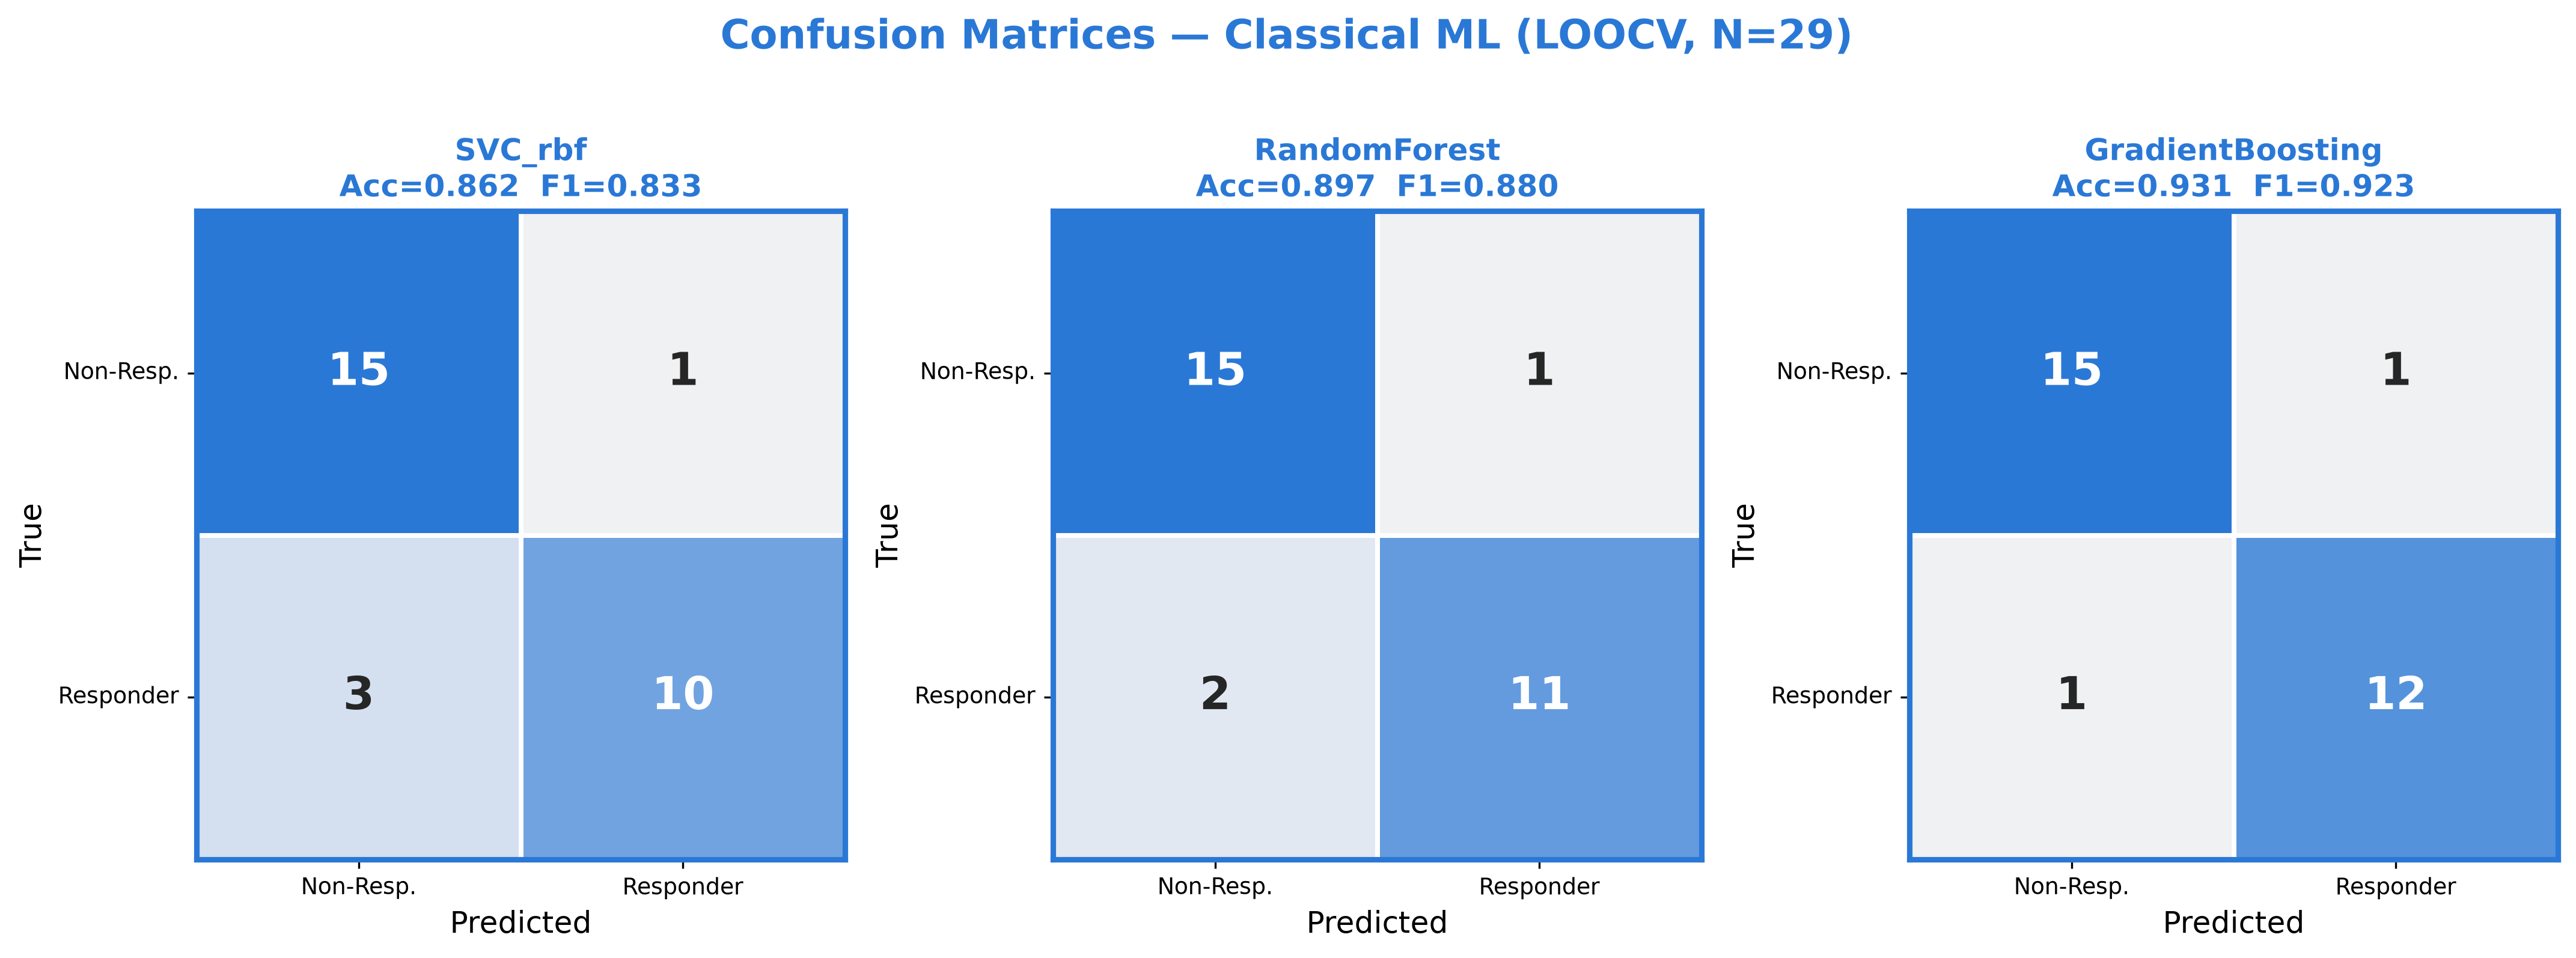

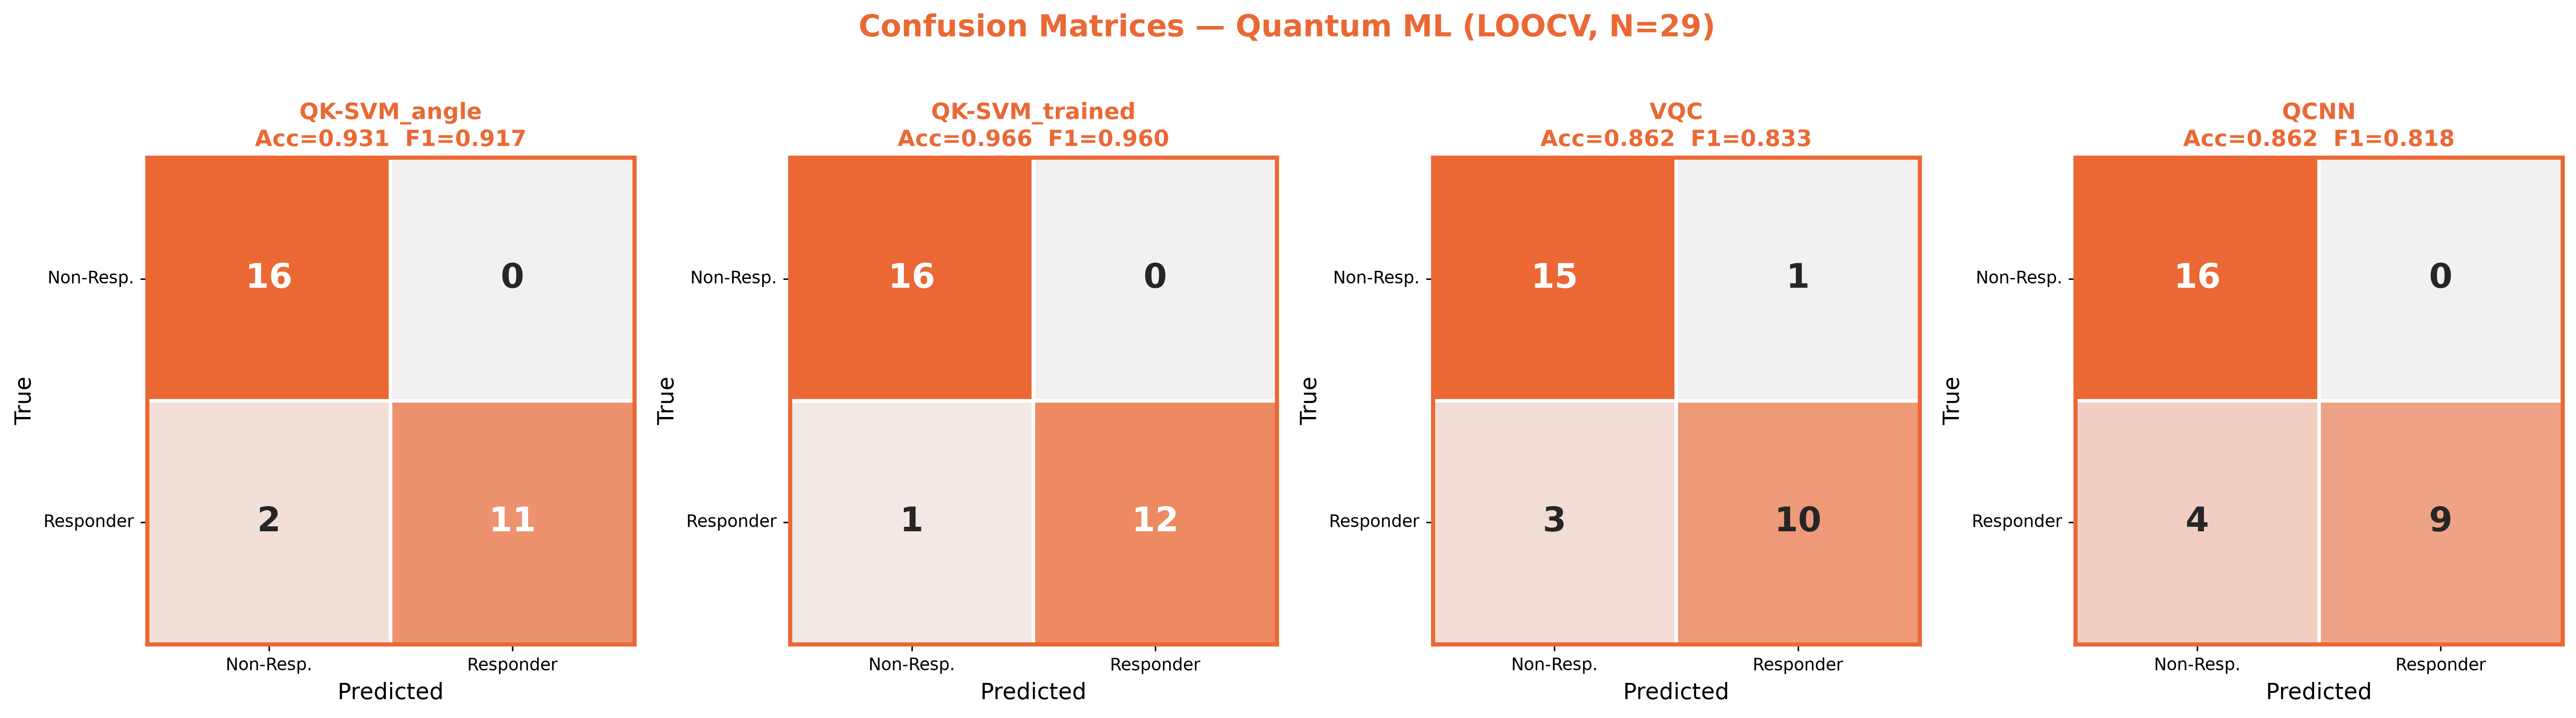

In [16]:
# Confusion matrices: where exactly each model's mistakes are (false alarms vs. missed
# Responders -- the costlier mistake here, since it means skipping a real formulation win).
show(
    PLOTS_DIR / "comparison" / "confusion_matrices_classical.png",
    PLOTS_DIR / "comparison" / "confusion_matrices_quantum.png",
)

## 9. Which drugs are hardest to predict?

Stacking every model's per-drug correctness together shows whether mistakes cluster on a few
genuinely hard drugs, or are scattered randomly.

In [17]:
hardest = pd.read_csv(RESULTS_DIR / "hardest_drugs.csv")
hardest.sort_values("misclassified_of_7", ascending=False).head(5)

,drug,misclassified_of_7,mean_abs_err_reg,mean_pct_err_reg,true_COMDR15,label,D50,MolLogP,Kappa3,apparent_solubility,difficulty_score
1,Etoricoxib,7,0.61,26.3,2.31,1,10.89,4.1759,3.4711,113.0,1.263000
3,Ezetimibe,4,0.90,29.6,3.05,1,7.88,4.8883,3.9104,9.5,0.867429
4,Dipyridamole,2,2.28,57.6,3.96,1,64.35,-0.0176,6.0499,12.8,0.861714
11,Sertraline,2,0.35,22.6,1.55,0,49.05,5.1796,2.4604,202.0,0.511714
6,Dasatinib,2,0.90,55.2,1.63,0,3.62,3.3135,5.7722,78.4,0.837714


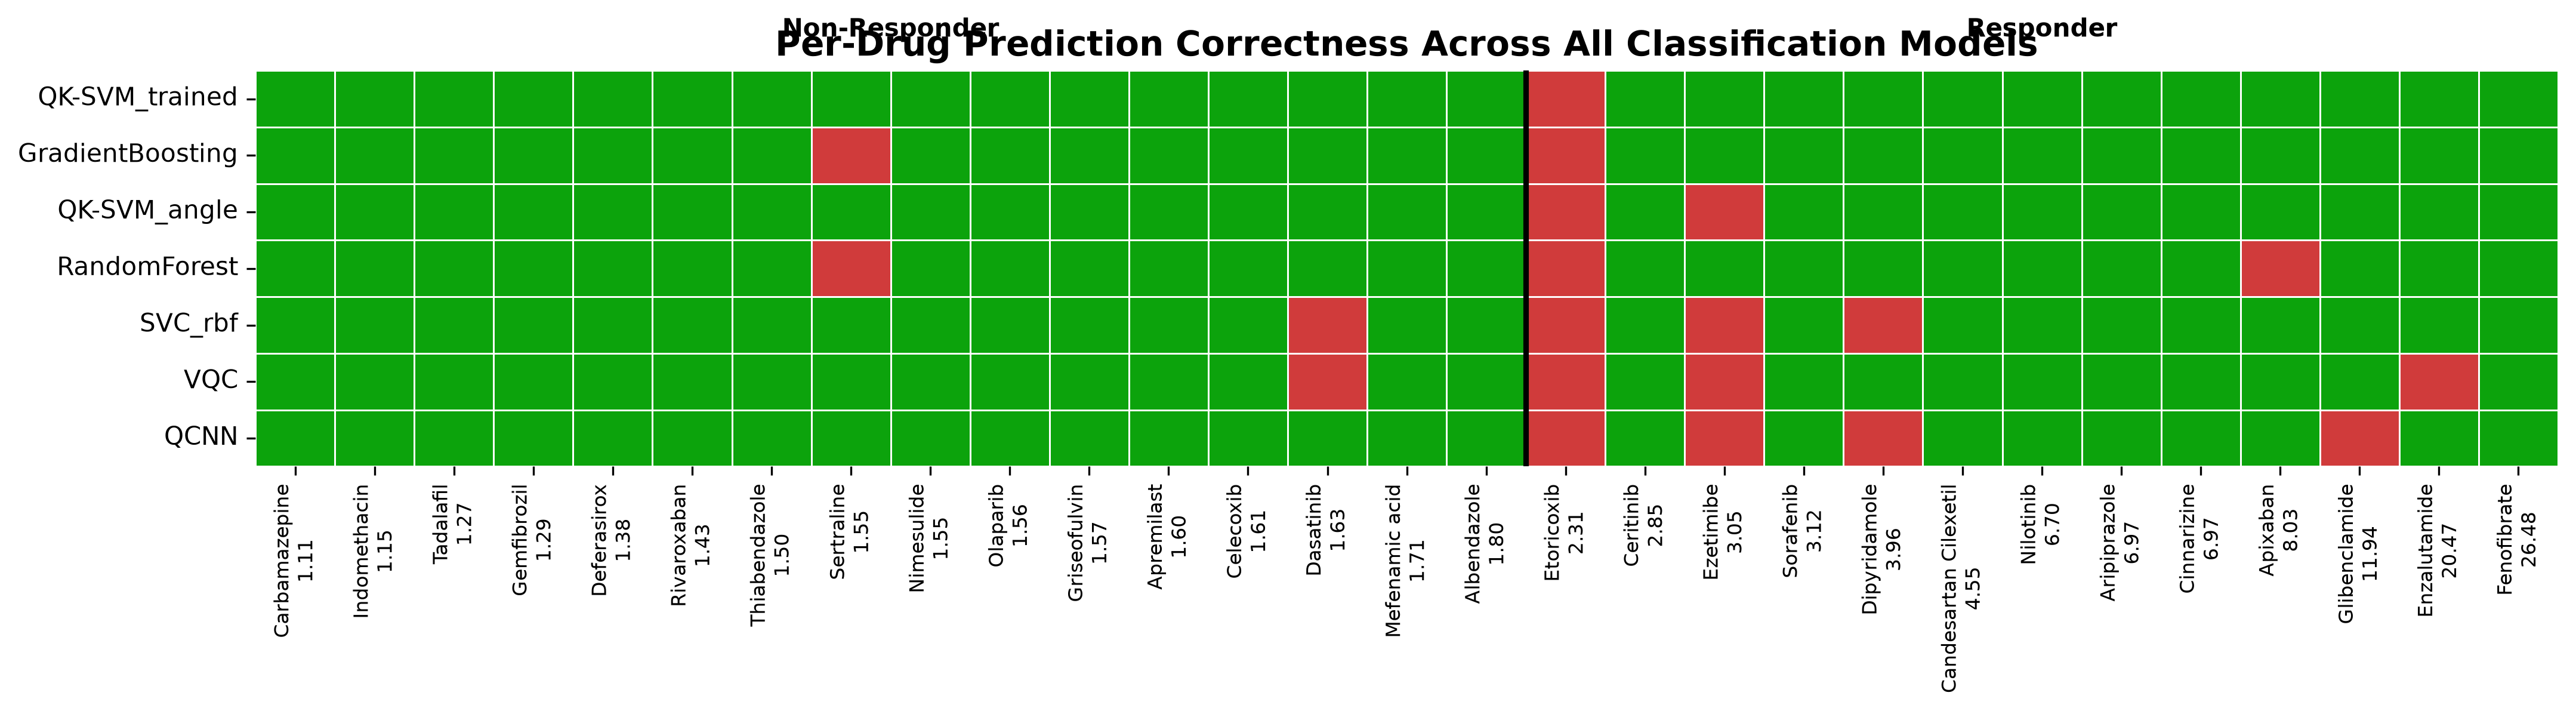

In [18]:
show(PLOTS_DIR / "comparison" / "per_drug_classification_heatmap.png")

## 10. Regression: predicting the exact ratio

Beyond the yes/no label, we also try to predict `COMDR_15min` itself as a number. This is
scored with **Q<sup>2</sup>** (LOOCV R<sup>2</sup> &mdash; how much better than "always guess
the average" a model is) against the **Q<sup>2</sup> = 0.77** benchmark from Pätzmann et al.
2024, the paper this dataset comes from.

In [19]:
unified[unified["task"] == "regression"].sort_values("q2", ascending=False)

,task,model,paradigm,accuracy,f1,recall_0,recall_1,q2,r2,mae,rmse,elapsed_s
10,regression,PLS_regression,classical,NaN,NaN,NaN,NaN,0.7563,0.8279,1.8672,3.6382,0.0
8,regression,VQR_spsa_cobyla,quantum,NaN,NaN,NaN,NaN,0.5998,0.8629,2.7586,5.7615,258.4
9,regression,QCNN-R,quantum,NaN,NaN,NaN,NaN,0.5129,0.8068,2.6333,5.5068,436.0
7,regression,QK-KRR_angle,quantum,NaN,NaN,NaN,NaN,0.3646,0.7562,2.8286,6.2427,31.2


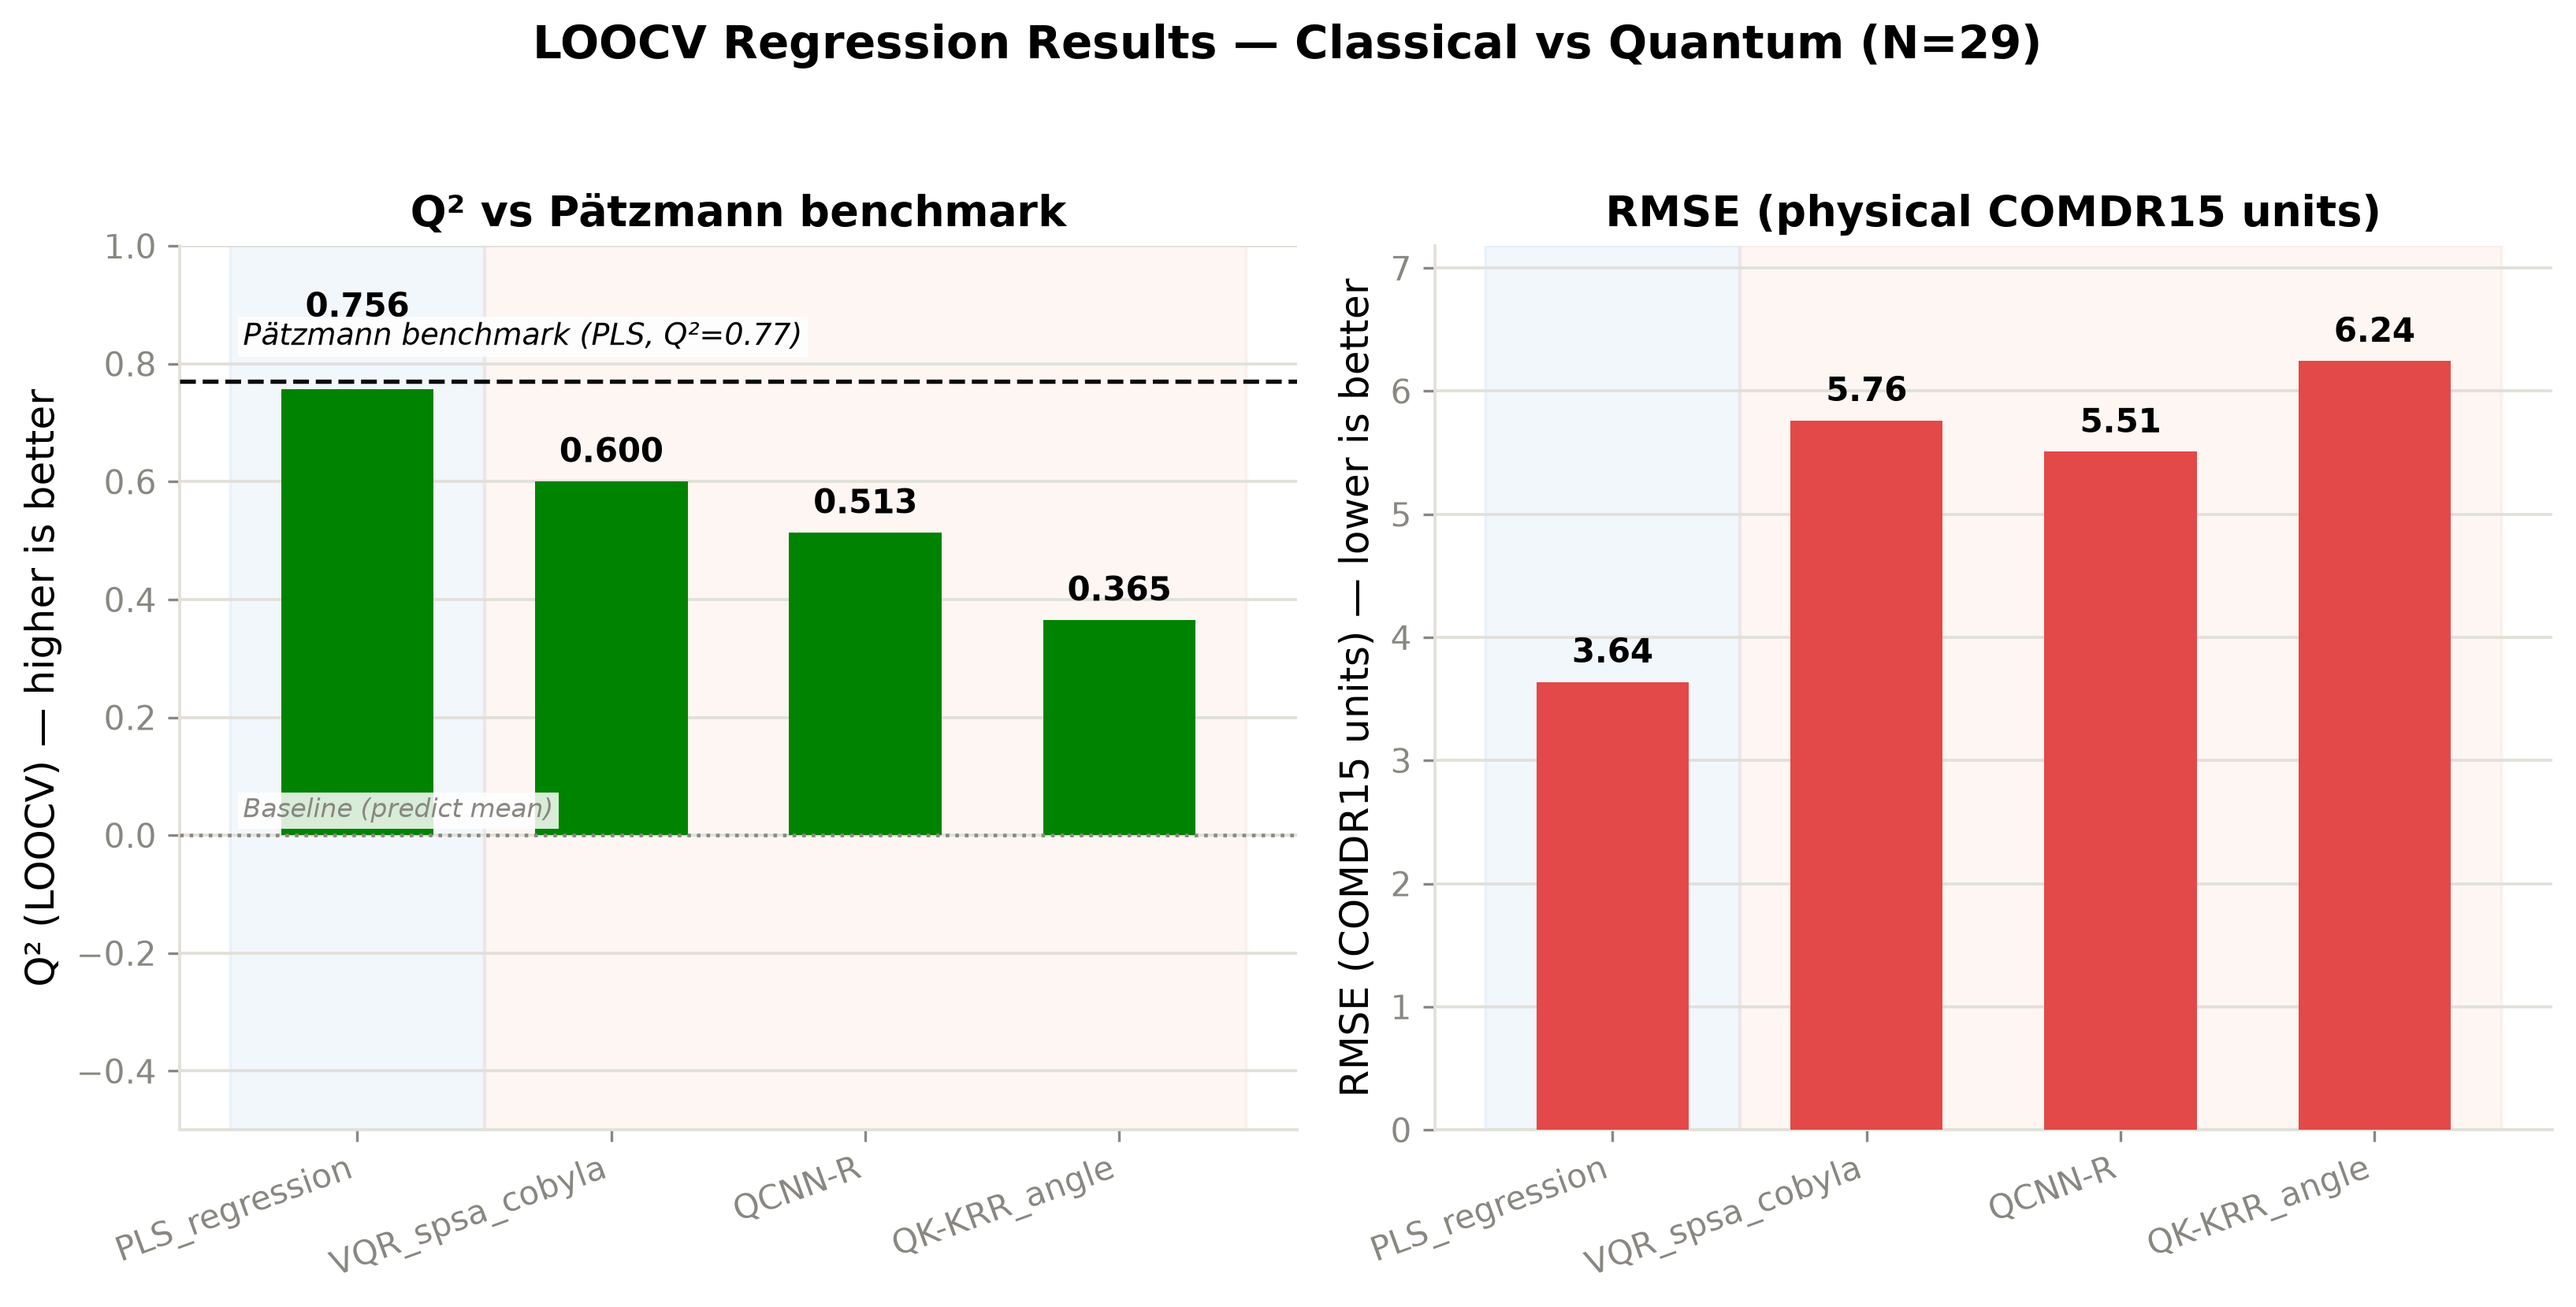

In [20]:
show(PLOTS_DIR / "comparison" / "regression_comparison.png")

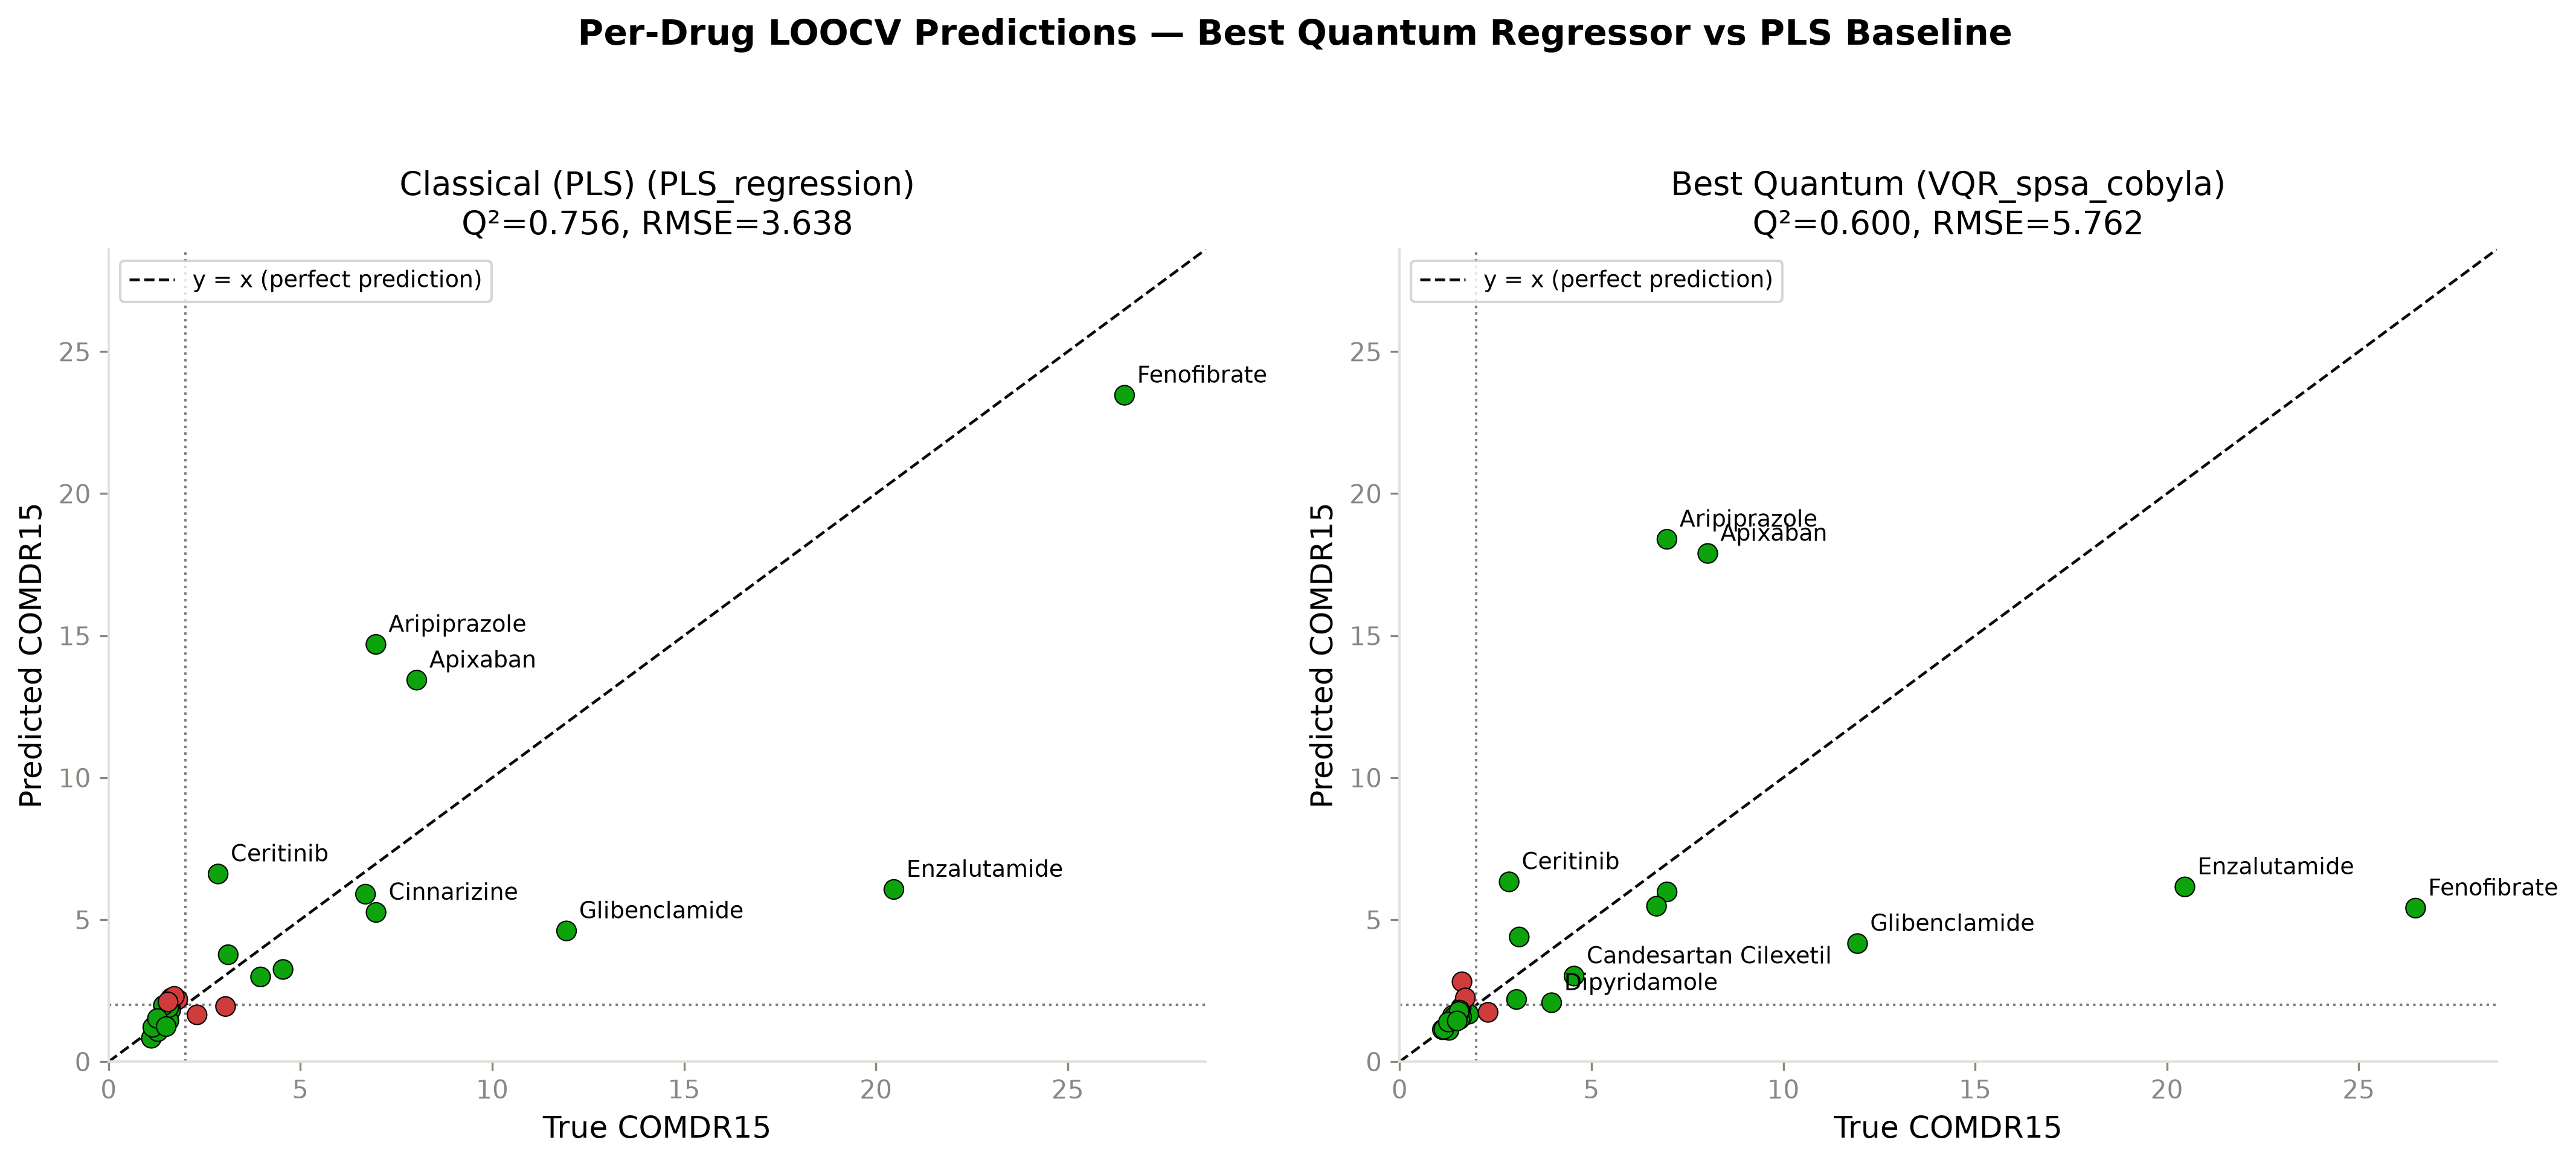

In [21]:
# Predicted vs. true ratio, one point per drug, for the classical PLS baseline vs. the best
# quantum regressor. Points on the diagonal are perfect predictions.
show(PLOTS_DIR / "comparison" / "per_drug_regression_scatter.png")

## 11. Bonus: training the quantum kernel itself

Instead of a fixed feature map, `QK-SVM (trained)` gives the encoding circuit its own weight
parameters and optimizes them with COBYLA to maximize KTA on the training data only, before the
SVM is fit. Like the quantum classifier demo above, the cell below runs this live but on a
small subset (10 drugs, fewer iterations) so it finishes in well under a minute; the real
30-second-plus optimization on all 29 drugs is what produced the plot underneath it.

In [22]:
kta_executor = QuantumExecutor(EXECUTION_CONFIG)
kta_model = KTAOptimizedQuantumKernel(executor=kta_executor, n_layers=2, maxiter=15)
kta_model.fit(X_scaled[:10], y.values[:10])
print(f"KTA before training: {kta_model.kta_before_:.4f}")
print(f"KTA after training:  {kta_model.kta_after_:.4f}")

KTA before training: 0.3220
KTA after training:  0.4906


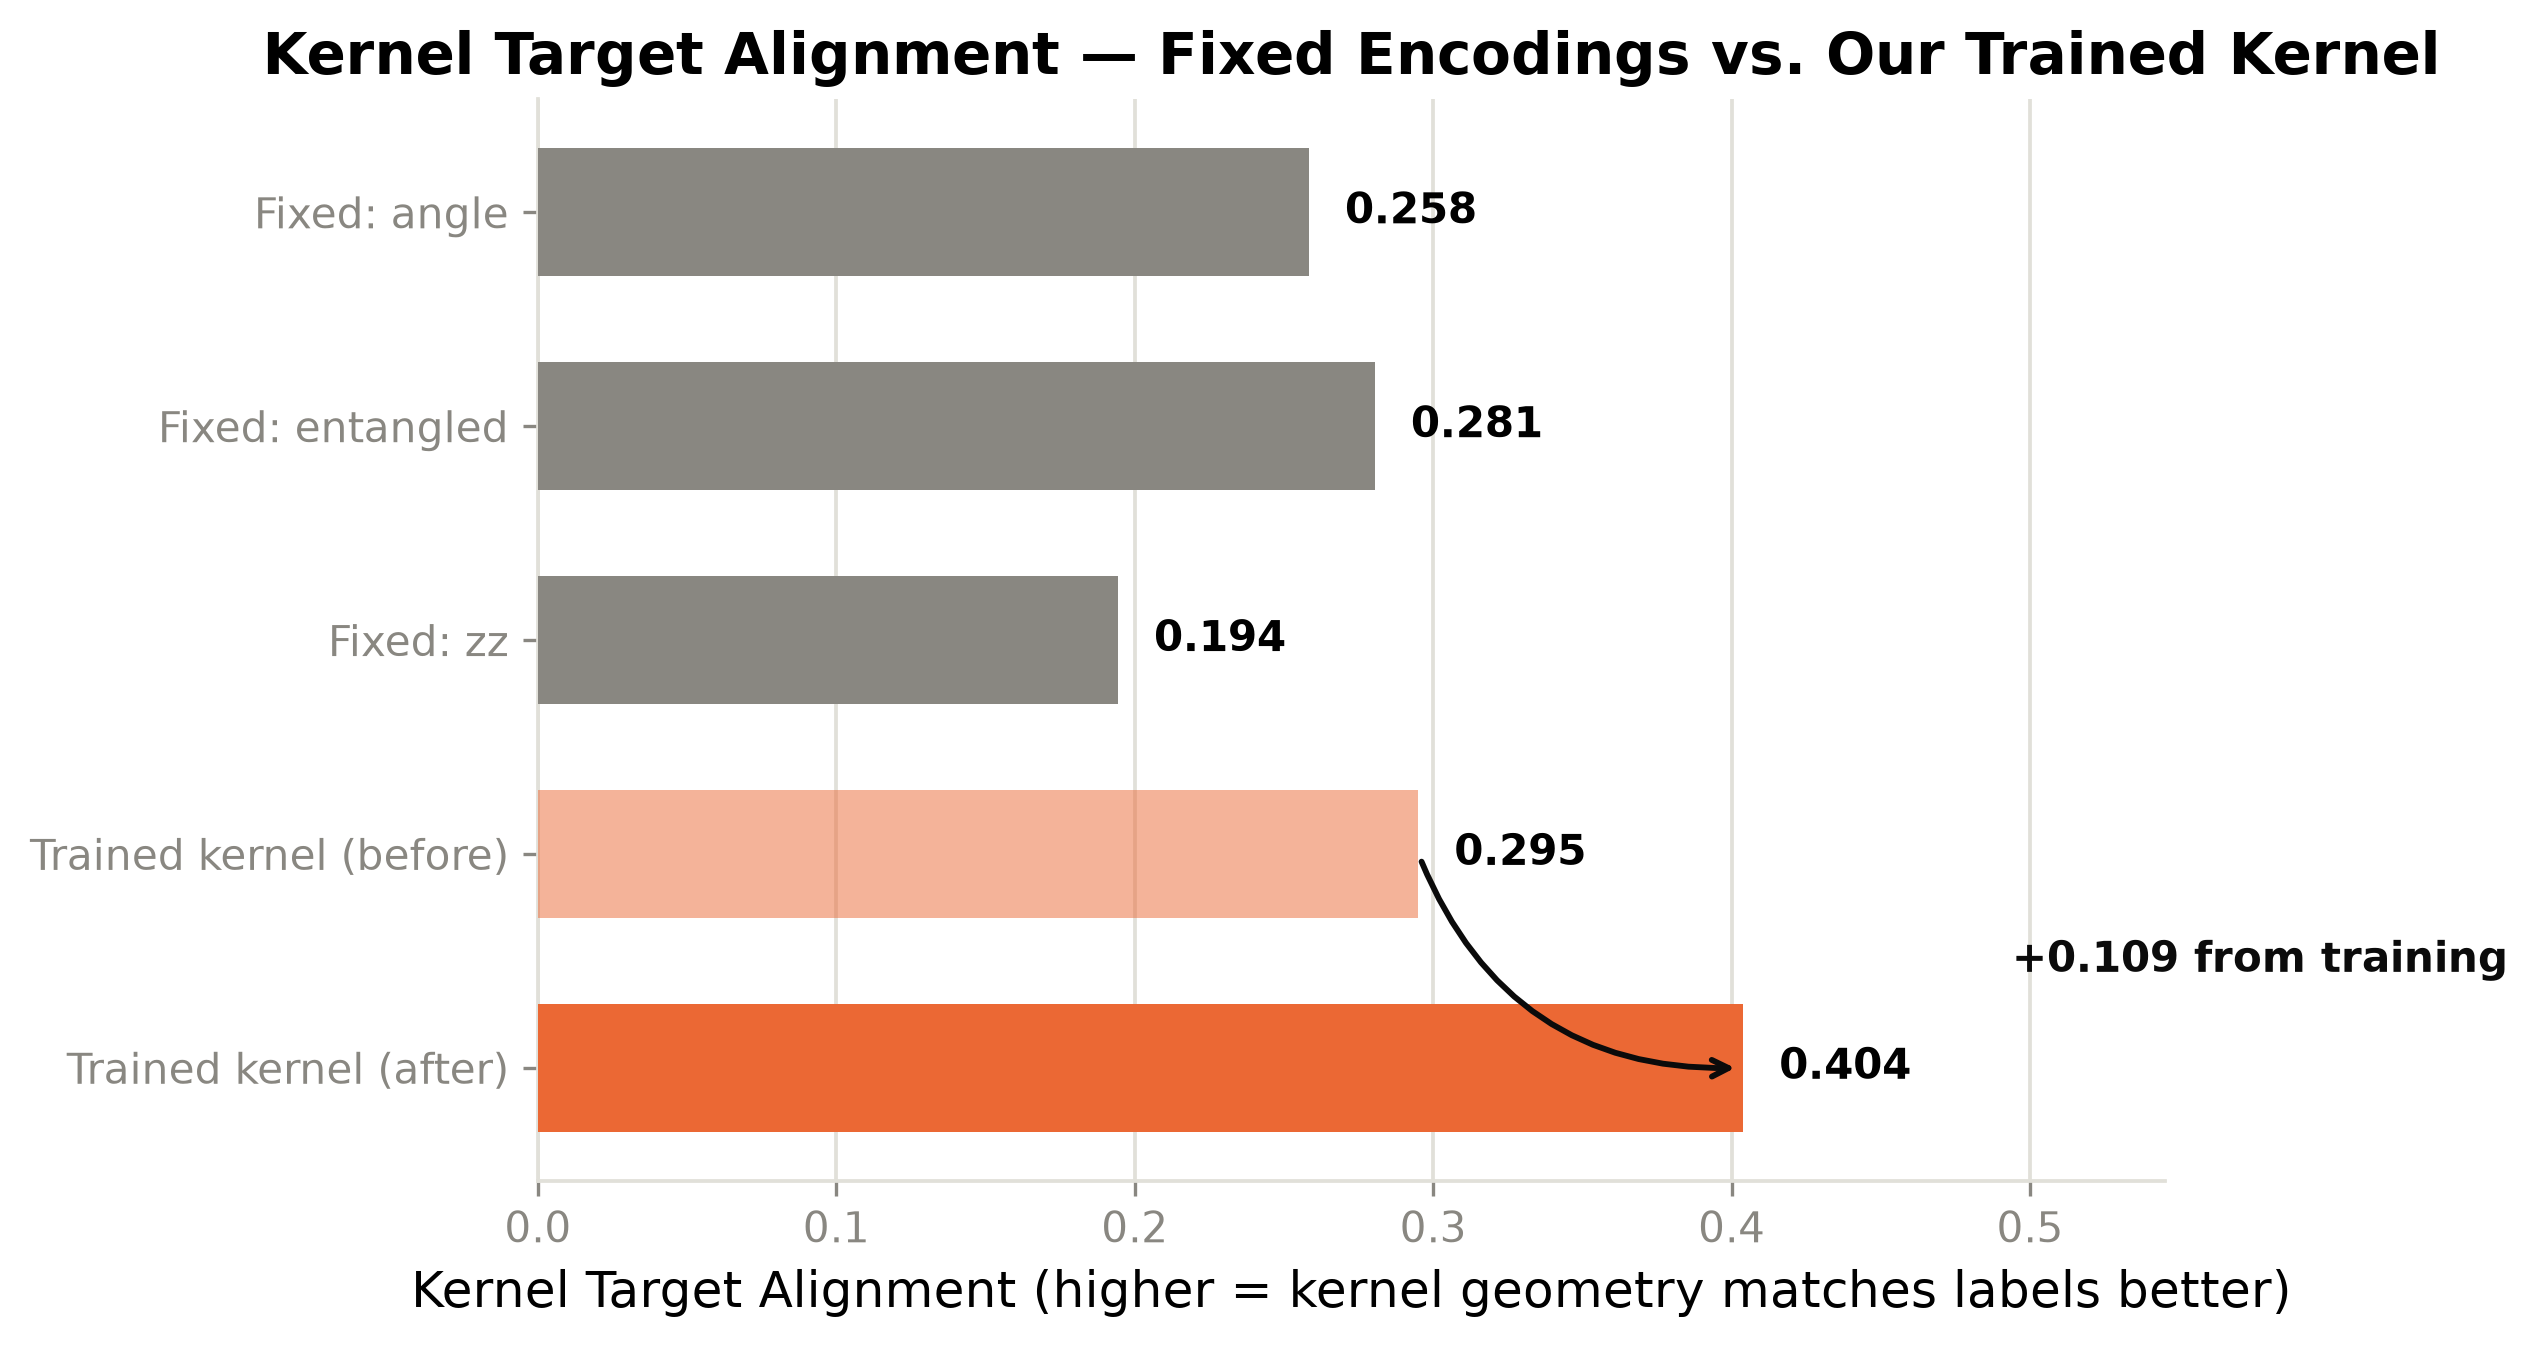

In [23]:
# The real thing: fixed encodings vs. the trained kernel, before/after optimization, on all 29 drugs.
show(PLOTS_DIR / "comparison" / "kta_comparison.png")

## 12. Bonus: how much does noise (or real hardware) hurt?

The exact same code that ran on the ideal simulator above can point at a device-realistic noisy
simulator, or real IBM Quantum hardware, just by changing `ExecutionConfig`. This compares
accuracy under both. Again using a small subset of drugs here so it runs in seconds; the
`--stage bonus` pipeline run does this same comparison on all 29 drugs.

In [24]:
degradation_result = execution_degradation_study(
    X.values[:12], y.values[:12], feature_map_name="angle", n_splits=3,
)
print(f"Ideal simulator accuracy: {degradation_result['baseline_accuracy_mean']:.3f}")
print(f"Noisy simulator accuracy: {degradation_result['comparison_accuracy_mean']:.3f}")
print(f"Degradation: {degradation_result['degradation']:.3f}")

Ideal simulator accuracy: 1.000
Noisy simulator accuracy: 1.000
Degradation: 0.000


## 13. Bonus: blind prediction from a SMILES string

A practical demo: given a brand-new drug's SMILES string (not one of the 29 training drugs)
and its measured particle size, predict Responder / Non-Responder with a confidence score.

In [25]:
model, scaler = fit_deployment_model(make_svc, X, y.values)
blind = BlindPredictor(model, scaler, selection["selected_features"])

demo_experimental_values = {"D50": 50.0, "apparent_solubility": 10.0}
kwargs = {f: v for f, v in demo_experimental_values.items() if f in selection["selected_features"]}

for name, smiles in {
    "Aspirin": "CC(=O)OC1=CC=CC=C1C(=O)O",
    "Ibuprofen": "CC(C)CC1=CC=C(C=C1)C(C)C(=O)O",
}.items():
    result = blind.predict(smiles, **kwargs)
    print(f"{name}: {result['prediction']} (confidence={result['confidence']:.3f})")

Aspirin: Non-Responder (confidence=0.134)
Ibuprofen: Non-Responder (confidence=0.187)


## Summary

- **Classification:** the KTA-trained quantum kernel (`QK-SVM (trained)`) reached **96.6%
  LOOCV accuracy**, ahead of the best classical model, Gradient Boosting, at **93.1%**. Every
  quantum classifier's ROC-AUC is competitive with or ahead of chance by a wide margin.
- **Regression:** classical PLS (Q<sup>2</sup> = 0.76) stays closest to the Pätzmann benchmark
  (0.77); the best quantum regressor (VQR) reaches Q<sup>2</sup> = 0.60. Regression is the
  harder problem for the quantum models here, most likely because 28 LOOCV training samples is
  a tight budget for a variational model's parameters.
- **On this 29-drug dataset, quantum kernel methods matched or slightly beat classical
  baselines on classification, and trailed on regression.** With only 29 samples, treat these
  as a genuine, fully-real result on this dataset &mdash; not yet a general claim about quantum
  advantage.

**To reproduce everything from scratch:** `python main.py --stage all` (see the project
[README](../README.md) for details, including how to point this at real IBM Quantum hardware).
For a closer look at any one part, see `notebooks/01`&ndash;`03`, or rebuild just the
comparison plots with `python scripts/plot_model_comparison.py`.